# 1D CNN — prepoznavanje emocija iz govora

Klasifikacija emocija na RAVDESS skupu podataka pomoću **1D konvolucione neuronske mreže**. Za razliku od KNN i Naive Bayes modela, CNN ne koristi agregirane statistike već **celu vremensku sekvencu** Mel-spektrograma, pa mreža sama uči vremenske obrasce karakteristične za pojedine emocije.

## Karakteristike i podela na skupove

Ulaz je puna sekvenca Mel-spektrograma (259 vremenskih okvira × 128 mel-frekvencija) po zapisu, umesto svedenih statistika. Podela na skupove je ista actor-independent podela (16/4/4 glumaca), a standardizacija (StandardScaler) se fituje isključivo na trening skupu, po mel-frekvencijskom pojasu.

## Arhitektura i treniranje

Tri konvoluciona sloja (Conv1D, kernel veličine 20) sa L2 regularizacijom, max-pooling i dropout slojevima, praćeni global average pooling-om i potpuno povezanim slojem. Trening koristi `EarlyStopping` (na osnovu validacionog gubitka) da spreči overfitting — validacioni skup ovde ostaje odvojen od trening skupa jer je aktivno potreban tokom treninga za odlučivanje kada zaustaviti učenje.

In [ ]:
import os
import numpy as np
from tensorflow.keras.layers import GlobalAveragePooling1D, Conv1D, MaxPooling1D, Dropout, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

output_dir = "models/cnn"
os.makedirs(output_dir, exist_ok=True)

data_dir = "data/processed_data/cnn"
X_train = np.load(os.path.join(data_dir, "X_train_cnn.npy"))
y_train = np.load(os.path.join(data_dir, "y_train_cnn.npy"))
X_val   = np.load(os.path.join(data_dir, "X_val_cnn.npy"))
y_val   = np.load(os.path.join(data_dir, "y_val_cnn.npy"))
X_test  = np.load(os.path.join(data_dir, "X_test_cnn.npy"))
y_test  = np.load(os.path.join(data_dir, "y_test_cnn.npy"))

le = LabelEncoder()
le.fit(['neutral', 'calm', 'happy', 'sad', 'angry', 'fear', 'disgust', 'surprise'])
y_train_int = le.transform(y_train)
y_val_int   = le.transform(y_val)
y_test_int  = le.transform(y_test)

num_classes = len(le.classes_)
y_train_enc = to_categorical(y_train_int, num_classes=num_classes)
y_val_enc   = to_categorical(y_val_int, num_classes=num_classes)
y_test_enc  = to_categorical(y_test_int, num_classes=num_classes)

X_train = X_train[:, :, np.newaxis] if X_train.ndim == 2 else X_train
X_val   = X_val[:, :, np.newaxis] if X_val.ndim == 2 else X_val
X_test  = X_test[:, :, np.newaxis] if X_test.ndim == 2 else X_test

input_shape = X_train.shape[1:]

model = Sequential([
    Conv1D(64, kernel_size=20, activation='relu', input_shape=input_shape),
    Conv1D(128, kernel_size=20, activation='relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)),
    MaxPooling1D(pool_size=8),
    Dropout(0.4),
    Conv1D(128, kernel_size=20, activation='relu'),
    MaxPooling1D(pool_size=8),
    Dropout(0.4),
    GlobalAveragePooling1D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax'),
])

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ModelCheckpoint(os.path.join(output_dir, "cnn_model.h5"), monitor='val_loss', save_best_only=True),
]

history = model.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=50, batch_size=64, callbacks=callbacks,
)
model.save(os.path.join(output_dir, "cnn_model.h5"))


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_enc)
print(f"Test accuracy: {test_acc*100:.2f}%")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_enc, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("CNN - Test Confusion Matrix")
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
plt.show()

train_loss = history.history['loss']; val_loss = history.history['val_loss']
train_acc = history.history['accuracy']; val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(6, 5))
plt.plot(epochs_range, train_loss, 'b', label='Train loss')
plt.plot(epochs_range, val_loss, 'r', label='Val loss')
plt.legend(); plt.title('Loss')
plt.savefig(os.path.join(output_dir, "loss_plot.png"))
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(epochs_range, train_acc, 'b', label='Train acc')
plt.plot(epochs_range, val_acc, 'r', label='Val acc')
plt.legend(); plt.title('Accuracy')
plt.savefig(os.path.join(output_dir, "accuracy_plot.png"))
plt.show()


## Rezultati

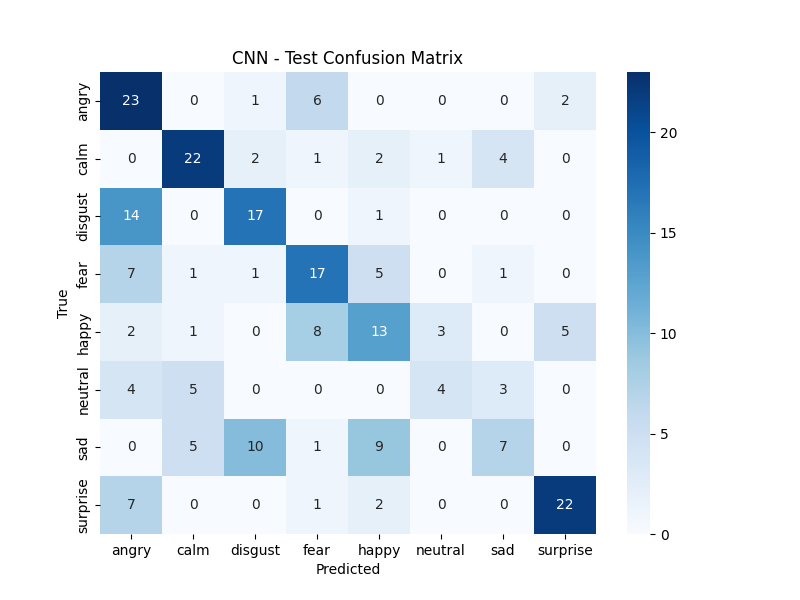

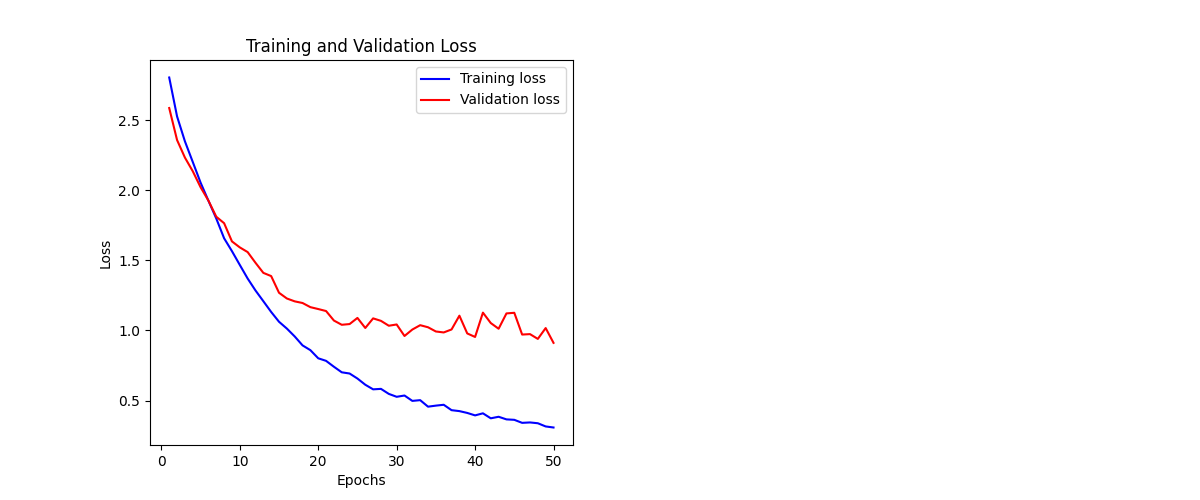

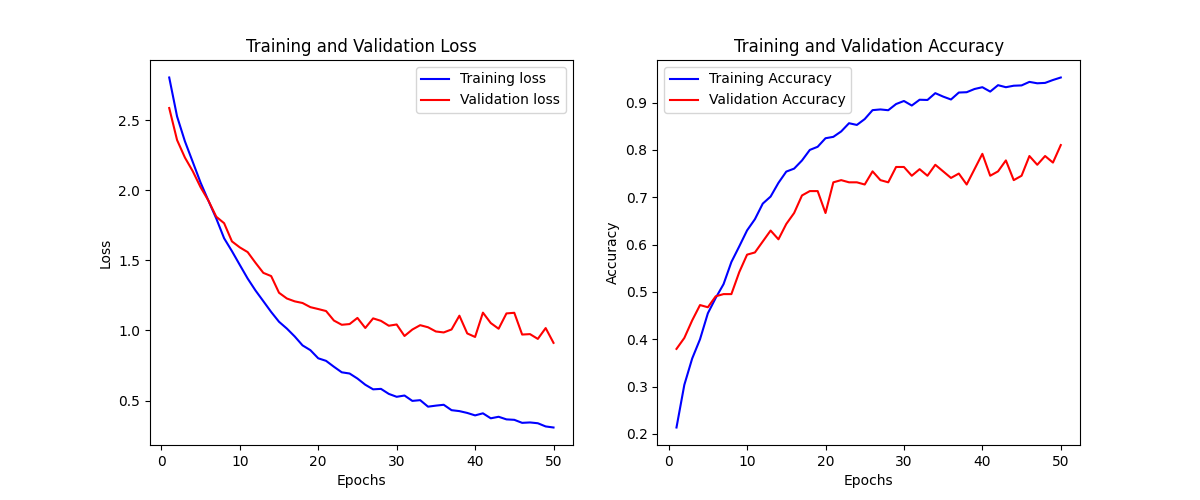

In [1]:
from IPython.display import Image, display
display(Image(filename="models/cnn/confusion_matrix.png"))
display(Image(filename="models/cnn/loss_plot.png"))
display(Image(filename="models/cnn/accuracy_plot.png"))


## Zaključak

CNN model postiže **52.1%** tačnosti na test skupu (actor-independent) — jasno bolje od KNN-a (39.2%) i Naive Bayes-a (33.3%). Ovo je očekivano: za razliku od ta dva modela, CNN ne radi sa svedenim statistikama već uči direktno iz pune vremenske sekvence Mel-spektrograma, pa može da prepozna obrasce u dinamici govora (npr. promenu energije i intonacije tokom vremena) koji se gube kada se spektrogram svede na mean/std/max.

I dalje, ~960 originalnih trening zapisa je mali skup za treniranje neuronske mreže od nule, pa je `EarlyStopping` ključan da spreči overfitting. Dalji, veći skok u tačnosti zahteva pristup koji ne uči isključivo od nule na ovom skupu — što je motivacija za Wav2Vec2 model (transfer learning) predstavljen posebno.